
## Lab1.1: Análisis exploratorio de datos con PANDAS y NUMPY

In [2]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = sns.load_dataset("penguins").dropna().values
df = pd.DataFrame(data, columns=["especie", "isla", "longitud_pico (mm)", "profundidad_pico (mm)", "longitud_aleta (mm)", "masa_corporal (g)", "genero"])

df[:5]

,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


Esto cargará un dataframe (df), usando la librería seaborn, con algunas características morfológicas y geográficas de diferentes especies de pingüinos. Las colujmnas contienen los siguientes datos:

```
[especie, isla, longitud del pico, profundidad del pico, longitud de la aleta, masa corporal, genero]
```

## Laboratorio_1.1

https://github.com/allisonhorst/palmerpenguins/blob/main/man/figures/lter_penguins.png



1.   ¿Cuáles son las profundidades del pico máxima y mínima de los pinguinos de la isla Torgersen?


In [15]:
df_islands = df.groupby('isla')
df_islands['profundidad_pico (mm)'].agg(['min', 'max']).loc['Torgersen']

min    15.9
max    21.5
Name: Torgersen, dtype: object

In [10]:
df.columns

Index(['especie', 'isla', 'longitud_pico (mm)', 'profundidad_pico (mm)',
       'longitud_aleta (mm)', 'masa_corporal (g)', 'genero'],
      dtype='str')


2.    ¿De qué isla, especie y género es el pingüino con la mayor masa corporal?
       **Ayuda:** utilice la función `argmax()`


In [17]:
df.sort_values(by='masa_corporal (g)', ascending=False).head(1)[['isla', 'especie', 'genero']]

,isla,especie,genero
231,Biscoe,Gentoo,Male



3.   ¿Cuál es la masa corporal media de los pinguinos macho que no son de la especie Gentoo?


In [19]:
df_no_gentoo = df[df['especie'] != 'Gentoo']
df_no_gentoo['masa_corporal (g)'].mean()

np.float64(3714.7196261682243)


4.   Grafique la distribución de la longitud del pico. Añada el valor medio y la desviación estándar en el título de la figura. **Ayuda:** utilice la funcion `hist()`


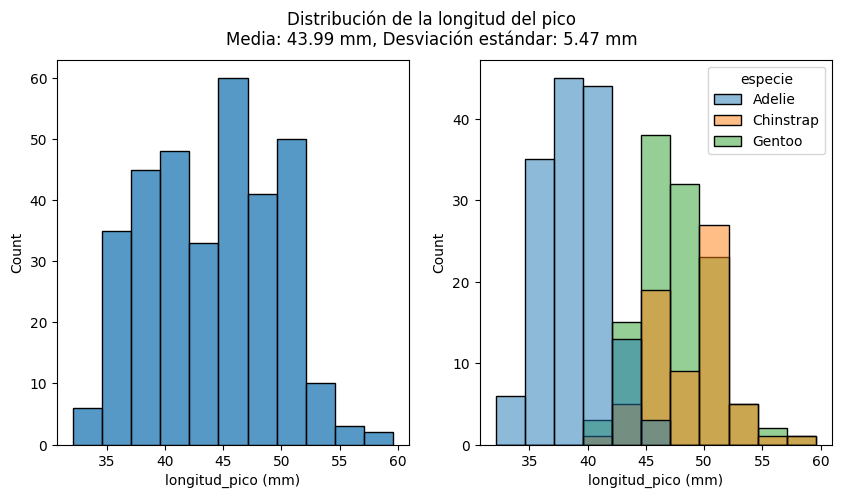

In [32]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

sns.histplot(data=df, x='longitud_pico (mm)', ax=ax[1], hue='especie')
sns.histplot(data=df, x='longitud_pico (mm)', ax=ax[0])
plt.suptitle(f'Distribución de la longitud del pico\nMedia: {df["longitud_pico (mm)"].mean():.2f} mm, Desviación estándar: {df["longitud_pico (mm)"].std():.2f} mm')
plt.show()



5.   ¿Cuáles son las islas y especies presentes en el conjunto de datos? ¿Con qué frecuencia aparecen? Grafique la distribución de la masa corporal para los pingüinos.




  



In [34]:
df_islands['especie'].value_counts()

isla       especie  
Biscoe     Gentoo       119
           Adelie        44
Dream      Chinstrap     68
           Adelie        55
Torgersen  Adelie        47
Name: count, dtype: int64

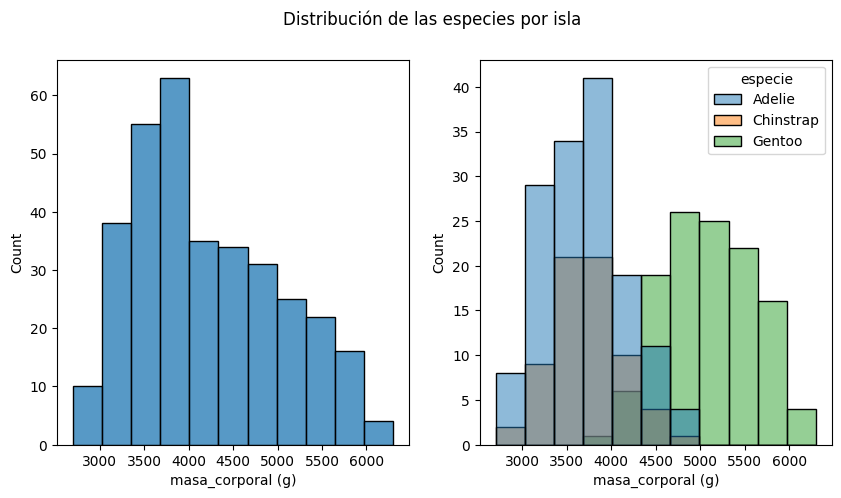

In [44]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

sns.histplot(data=df, x='masa_corporal (g)', ax=ax[0])
sns.histplot(data=df, x='masa_corporal (g)', ax=ax[1], hue='especie')
plt.suptitle('Distribución de las especies por isla')
plt.show()


